# Integrating ODEs with SciPy's `solve_ivp`

**CHME 5137, Lecture 8, Tuesday October 6, 2026.**

So far this term you have written your own integrators: Euler (Lecture 3) and
2-step Adams–Bashforth (Assignment 3). Writing them was how you learned what
a step size is, what convergence means, and why a method goes unstable. From now on,
for real work, you will mostly call a library instead. The library has had decades of
work put into it. It chooses its own step sizes, estimates its own error, and has
methods for stiff problems. You still have to understand what it is doing, because
**you choose how accurate the answer has to be**, and the defaults are not always
good enough.

*This notebook was revised for 2026 by Claude Code (Claude Opus 5.5) from the 2025
version, and checked by Prof. West. The packed-bed example and much of the text
date from earlier years. New in 2026: the decay example (so it matches Lecture 3),
the tolerance table, the stiff example, and the jupytext pairing.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## What `solve_ivp` solves

It integrates a system of first-order ODEs

$$\frac{d\mathbf{y}}{dt} = \mathbf{f}(t, \mathbf{y}), \qquad \mathbf{y}(t_0) = \mathbf{y}_0$$

where $\mathbf{y}$ is a vector of any length. Any higher-order ODE can be put into
this form by adding variables for the derivatives (Lecture 3).

You must write a Python function `f(t, y)` that takes the time `t` (even if it
doesn't use it) and the vector `y`, and returns the vector of derivatives.
**The order of the arguments is `t` first, then `y`.**

> The older `scipy.integrate.odeint` uses the opposite order, `f(y, t)`. You will
> find it in old code, old textbooks and AI answers. For new code SciPy recommends
> `solve_ivp`.

## 1. A problem whose answer we know

The decay equation from Lecture 3, $dc/dt = -kc$, with $c(0) = 1$ and
$k = 0.5$. The exact answer is $c(t) = e^{-kt}$.

In [ ]:
k = 0.5


def dcdt(t, c):
    "The right-hand side, dc/dt = -k c"
    return -k * c


c0 = [1.0]  # always a list (or array), even with one variable
t_span = (0, 10)  # start and end times, as a 'tuple'

sol = solve_ivp(dcdt, t_span, c0)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.149e-01  1.264e+00  3.061e+00  4.817e+00
             6.576e+00  8.338e+00  1.000e+01]
        y: [[ 1.000e+00  9.442e-01  5.316e-01  2.165e-01  9.005e-02
              3.738e-02  1.550e-02  6.754e-03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 44
     njev: 0
      nlu: 0

What came back is an object with several attributes. The ones you need most:

| attribute | what it is |
|---|---|
| `sol.t` | the times the solver chose, a 1-D array |
| `sol.y` | the solution, **one row per variable**: shape `(n_variables, n_times)` |
| `sol.success`, `sol.message` | did it work? **Always check.** |
| `sol.nfev` | how many times it called your function: a measure of cost |

True The solver successfully reached the end of the integration interval.
shape of sol.y: (1, 8)
function evaluations: 44


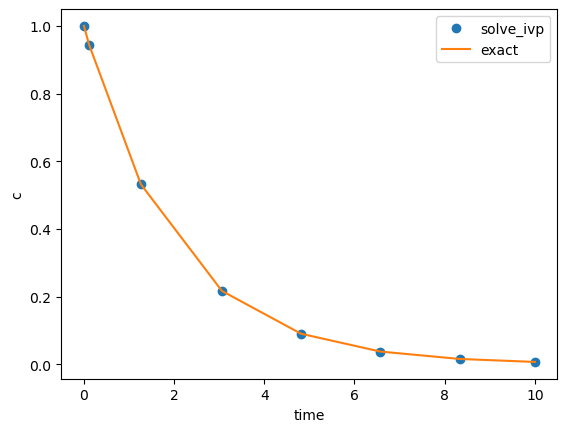

In [ ]:
print(sol.success, sol.message)
print("shape of sol.y:", sol.y.shape)
print("function evaluations:", sol.nfev)

c_exact = np.exp(-k * sol.t)
plt.plot(sol.t, sol.y[0], "o", label="solve_ivp")
plt.plot(sol.t, c_exact, label="exact")
plt.xlabel("time")
plt.ylabel("c")
plt.legend()
plt.show()

It took very few steps, and **chose them itself**: small at the start, where $c$
changes fast, and larger later. That's *adaptive step-size control*. At each step it
estimates its own error (by comparing two methods of different order), and shrinks
or grows the step to keep that estimate within a tolerance.

Compare Euler: on this problem it needs 10,000 steps of $\Delta t = 0.001$ to get
the answer at $t = 10$ right to 0.1%.

In [ ]:
error = sol.y[0] - c_exact
print(f"largest absolute error: {np.abs(error).max():.1e}")
print(f"relative error at t = 10: {error[-1] / c_exact[-1]:.1e}")

largest absolute error: 1.3e-04
relative error at t = 10: 2.4e-03


## 2. Required accuracy: `rtol` and `atol`

The solver keeps its estimated error in each variable at each step below roughly

$$\text{atol} + \text{rtol} \times |y|$$

- **`rtol`**, the *relative* tolerance, is the fraction of the value you are willing
  to get wrong. The default is `1e-3`, about three significant figures.
- **`atol`**, the *absolute* tolerance, matters when $y$ is near zero, where a
  relative error means nothing. The default is `1e-6`, **in whatever units your
  variables are in**. One millionth of a mole per litre, or of a fox, or of a
  kilogram.

Two warnings:

1. This is a tolerance on the error **per step**, estimated by the solver. Errors
   add up over many steps, so the error in your final answer can be larger.
   **You find out how accurate your answer is the same way you did with Euler:
   tighten the tolerance and see whether the answer changes.**
2. The defaults are often **not good enough for chemical kinetics**, where
   concentrations span many orders of magnitude and the small ones matter.

In [ ]:
print(f"{'rtol':>8} {'atol':>8} {'nfev':>6} {'steps':>6} {'rel. error at t=10':>20}")
for rtol in [1e-3, 1e-4, 1e-6, 1e-8, 1e-10]:
    sol = solve_ivp(dcdt, t_span, c0, rtol=rtol, atol=rtol * 1e-3)
    rel_err = (sol.y[0, -1] - np.exp(-k * 10)) / np.exp(-k * 10)
    print(f"{rtol:8.0e} {rtol * 1e-3:8.0e} {sol.nfev:6d} {len(sol.t):6d} {rel_err:20.1e}")

    rtol     atol   nfev  steps   rel. error at t=10
   1e-03    1e-06     44      8              2.4e-03
   1e-04    1e-07     68     12              1.9e-04
   1e-06    1e-09    140     24              1.3e-06
   1e-08    1e-11    332     56              1.1e-08
   1e-10    1e-13    812    136              1.1e-10


**Try it:** set `atol` large, say `1e-2`, and leave `rtol` small. What happens to
the error once $c$ falls below about 0.01? Why?

## 3. Getting the answer at the times *you* want

The solver's own time points are often too sparse for a smooth plot. Two ways
round that:

- `t_eval=` an array of times: the solution is reported at those times.
- `dense_output=True`: you get `sol.sol`, a function you can call at any time.

Neither makes the answer more accurate. The solver takes the same steps and
*interpolates* between them. Only `rtol` and `atol` control accuracy.

same number of function evaluations: 44 44


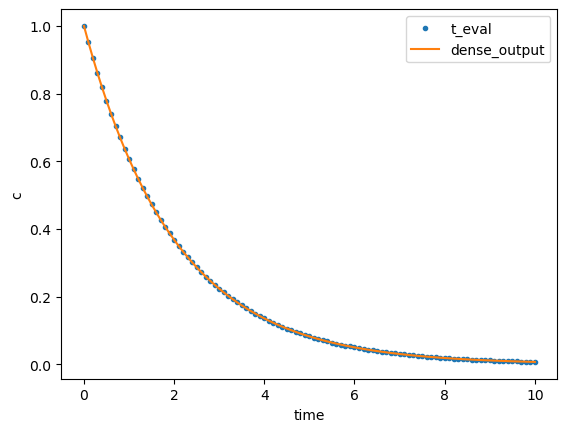

In [ ]:
times = np.linspace(0, 10, 101)
sol_eval = solve_ivp(dcdt, t_span, c0, t_eval=times)
sol_dense = solve_ivp(dcdt, t_span, c0, dense_output=True)
print("same number of function evaluations:", sol_eval.nfev, sol_dense.nfev)

plt.plot(sol_eval.t, sol_eval.y[0], ".", label="t_eval")
plt.plot(times, sol_dense.sol(times)[0], label="dense_output")
plt.xlabel("time")
plt.ylabel("c")
plt.legend()
plt.show()

## 4. A system: Fogler Example E5-7, a packed bed with pressure drop

*From "Essentials of Chemical Reaction Engineering" (2nd edition) by H. Scott
Fogler, pages 194–199.*

Two variables, conversion $X$ and pressure ratio $p = P/P_0$, and the independent
variable is the catalyst weight $W$, not time. `solve_ivp` doesn't care what you
call it.

$$\frac{dX}{dW} = \frac{-r_A'}{F_{A0}} \qquad
  \frac{dp}{dW} = -\frac{\alpha}{2p}(1+\epsilon X)$$

(Depending on which edition, the textbook might write $dy$ instead of $dp$ in the second equation.)

The solver successfully reached the end of the integration interval.


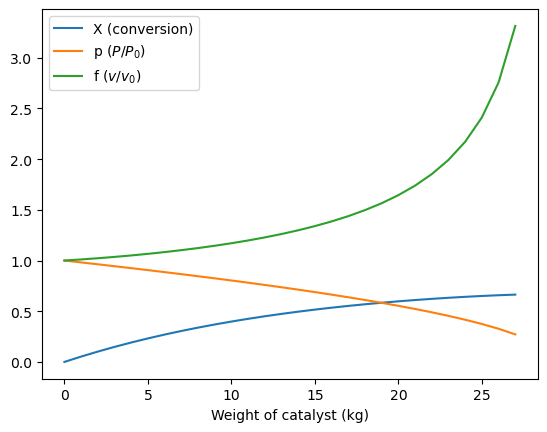

In [ ]:
def packed_bed(W, Y):
    """Right-hand side for Fogler E5-7.
    W is catalyst weight (kg, not used explicitly), Y is the vector [X, p]."""
    X, p = Y  # unpack the vector into two named variables
    epsilon = -0.15
    kprime = 0.0074
    Fa0 = 0.1362
    alpha = 0.0367
    raprime = -kprime * (1 - X) / (1 + epsilon * X) * p

    dXdW = -raprime / Fa0
    dpdW = -alpha * (1 + epsilon * X) / (2 * p)
    return [dXdW, dpdW]  # pack the derivatives, in the same order


W_points = np.linspace(0, 27.0, 28)
sol = solve_ivp(packed_bed, (0, 27.0), [0.0, 1.0], t_eval=W_points, rtol=1e-6, atol=1e-9)
print(sol.message)

X, p = sol.y  # one row per variable, so this unpacks them
f = (1 - 0.15 * X) / p  # volumetric flow rate ratio v/v0

plt.plot(sol.t, X, label="X (conversion)")
plt.plot(sol.t, p, label="p ($P/P_0$)")
plt.plot(sol.t, f, label="f ($v/v_0$)")
plt.legend(loc="upper left")
plt.xlabel("Weight of catalyst (kg)")
plt.show()

**Integrating other variables.** Sometimes it is convenient to integrate quantities
that are only intermediate values, such as a total number of moles or a volume,
alongside the ones you care about. Just add them to the vector.

## 5. Stiff problems: choosing `method`

The last part of Assignment 3 had two reactions in series, a fast A → B and a
slow B → C. For an explicit method, the stable step is set by the *fast* rate
constant, but the simulation has to run for as long as the *slow* one takes
(Lecture 7). That's a **stiff** problem.

`solve_ivp`'s default method, `"RK45"`, is explicit. Its error control keeps it
stable on a stiff problem, but only by taking tiny steps. The implicit methods
`"BDF"` and `"Radau"`, and `"LSODA"` (which switches between stiff and non-stiff
methods automatically), are built for this.

Watch the number of function evaluations as the fast rate constant goes up.

In [ ]:
def abc(t, y, ka, kb):
    "A -> B -> C, first order, rate constants ka and kb"
    A, B, C = y
    return [-ka * A, ka * A - kb * B, kb * B]


kb = 0.5
print(f"{'ka':>8} {'method':>7} {'nfev':>9} {'B(10)':>10}")
for ka in [20, 1e3, 1e5]:
    for method in ["RK45", "BDF", "LSODA"]:
        sol = solve_ivp(abc, (0, 10), [1.0, 0.0, 0.0], args=(ka, kb), method=method)
        print(f"{ka:8.0e} {method:>7} {sol.nfev:9d} {sol.y[1, -1]:10.6f}")

      ka  method      nfev      B(10)
   2e+01    RK45       452   0.006909
   2e+01     BDF       148   0.006902
   2e+01   LSODA       138   0.006881


   1e+03    RK45     21044   0.006741
   1e+03     BDF       173   0.006725
   1e+03   LSODA       152   0.006707


   1e+05    RK45   2101646   0.006737
   1e+05     BDF       178   0.006713
   1e+05   LSODA       158   0.006726


Notes on that cell:

- `args=(ka, kb)` passes extra parameters through to your function, after `t`
  and `y`. It saves writing a new function for each value.
- At $k_a = 10^5$ s⁻¹, `RK45` calls the function about two million times and
  `BDF` a couple of hundred. Same answer.
- The SciPy documentation's advice: if `RK45` takes an unusually large number of
  steps, diverges, or fails, your problem is probably stiff; try `"BDF"`,
  `"Radau"` or `"LSODA"`.
- For a non-stiff problem, an implicit method costs *more*: every step solves an
  equation. The rabbits-and-foxes exercise lets you check that.

**Most detailed chemical kinetics is stiff.** Free radicals, surface intermediates
and fast equilibria all bring time scales of microseconds or less into a
simulation that runs for seconds or hours.

## Now: `rabbits-and-foxes.ipynb`

Same equations as Lecture 3, this time with `solve_ivp`.